# 02. Analysis, Sensitivity, and Decision Support

**Back half of the project. This notebook is a scaffold, not finished work.**

Every section below has the setup written and a TODO for you. You should not need to touch the model: everything here is `solve_model()` called with different arguments.

Read `01_data_and_model.ipynb` first if you have not.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt

import data_prep
from model import solve_model, summarize
from plotting import plot_instance, plot_solution, plot_sweep

sites, demands, D = data_prep.load_all('../data')
print(f'loaded {len(sites)} sites, {len(demands)} demand points')

loaded 20 sites, 56 demand points


## 2.1 Compare the two modes

`min_cost` serves everyone at least cost. `max_coverage` fixes the budget and covers as much as it can. Same data, different modeling choice, different answer. That contrast is worth a table in the report.

**TODO**: run both at the same budget and fill in the comparison.

In [2]:
BUDGET, RADIUS = 700_000, 5.0

res_cost = solve_model(sites, demands, D, budget=BUDGET, radius=RADIUS, mode='min_cost')
res_cov  = solve_model(sites, demands, D, budget=BUDGET, radius=RADIUS, mode='max_coverage')

summarize(res_cost, sites, label='min_cost')
print()
summarize(res_cov, sites, label='max_coverage')

# TODO: build a small DataFrame comparing the two on
#       stations built / construction cost / coverage / average drive

[min_cost] status: Optimal
  stations built   : 6 of 20
  construction cost: $643,000
  demand covered   : 23,248 (100.0%)
  average drive    : 2.59 km
  objective        : 703,188

[max_coverage] status: Optimal
  stations built   : 6 of 20
  construction cost: $643,000
  demand covered   : 23,248 (100.0%)
  average drive    : 3.29 km
  objective        : 23,248


## 2.2 Budget sweep

The headline chart of the project. Sweep the budget and plot coverage against it, then say where the knee is: the point past which extra money buys almost nothing.

A quick check while building the front half gave about 34 percent coverage at \$200k, rising to 100 percent at \$700k, then flat. Confirm that and make it a proper figure.

**TODO**: finish the loop, plot it, and write one sentence naming the knee.

In [3]:
budgets = np.arange(150_000, 1_000_001, 50_000)
rows = []
for b in budgets:
    r = solve_model(sites, demands, D, budget=b, radius=RADIUS, mode='max_coverage')
    rows.append({'budget': b,
                 'status': r['status'],
                 'n_built': len(r['built']),
                 'coverage_pct': r['coverage_pct'],
                 'spent': r['total_cost'],
                 'avg_drive': r['avg_distance']})
sweep_budget = pd.DataFrame(rows)
sweep_budget.head(10)

,budget,status,n_built,coverage_pct,spent,avg_drive
0,150000,Optimal,1,17.205781,88000.0,3.692588
1,200000,Optimal,2,34.411562,181000.0,3.706425
2,250000,Optimal,2,34.411562,181000.0,3.706425
3,300000,Optimal,3,51.617343,276000.0,3.753784
4,350000,Optimal,4,53.337922,350000.0,3.423975
5,400000,Optimal,4,68.823125,371000.0,3.465679
6,450000,Optimal,5,70.543703,450000.0,3.581634
7,500000,Optimal,5,83.835169,488000.0,3.553192
8,550000,Optimal,5,86.028906,548000.0,3.255912
9,600000,Optimal,6,87.749484,597000.0,3.726286


In [4]:
# TODO: plot budget against coverage_pct, mark the knee
# plot_sweep(sweep_budget, 'budget', 'coverage_pct',
#            xlabel='budget ($)', ylabel='demand covered (%)',
#            title='Coverage bought per dollar of budget')
# plt.show()

## 2.3 Service radius sweep

How far are drivers willing to go? Below 4 km the problem becomes infeasible, which is itself a result worth reporting.

**TODO**: sweep the radius, tabulate, and plot.

In [5]:
radii = [3, 3.5, 4, 4.5, 5, 6, 7, 8]
rows = []
for R in radii:
    r = solve_model(sites, demands, D, budget=1_200_000, radius=R, mode='min_cost')
    rows.append({'radius_km': R, 'status': r['status'],
                 'n_built': len(r['built']), 'cost': r['total_cost'],
                 'avg_drive': r['avg_distance']})
sweep_radius = pd.DataFrame(rows)
sweep_radius

,radius_km,status,n_built,cost,avg_drive
0,3.0,Infeasible,0,NaN,NaN
1,3.5,Infeasible,0,NaN,NaN
2,4.0,Optimal,6,714000.0,2.091476
3,4.5,Optimal,6,704000.0,2.130544
4,5.0,Optimal,6,643000.0,2.588944
5,6.0,Optimal,6,633000.0,2.770937
6,7.0,Optimal,6,633000.0,2.749366
7,8.0,Optimal,6,595000.0,3.417042


## 2.4 Capacity sweep

Capacity is the assumption we are least sure about, so it deserves a stress test. `solve_model()` takes `capacity_scale`, so you do not have to edit the data.

**TODO**: sweep capacity_scale from 0.5 to 1.5 and report how the build count moves.

In [6]:
scales = [0.5, 0.75, 1.0, 1.25, 1.5]
rows = []
for s in scales:
    r = solve_model(sites, demands, D, budget=1_200_000, radius=RADIUS,
                    mode='min_cost', capacity_scale=s)
    rows.append({'capacity_scale': s, 'status': r['status'],
                 'n_built': len(r['built']), 'cost': r['total_cost']})
sweep_capacity = pd.DataFrame(rows)
sweep_capacity

,capacity_scale,status,n_built,cost
0,0.50,Infeasible,0,NaN
1,0.75,Optimal,8,910000.0
2,1.00,Optimal,6,643000.0
3,1.25,Optimal,5,548000.0
4,1.50,Optimal,4,450000.0


## 2.5 Maps

`plot_solution()` is already written. The strongest single figure is a low budget plan next to a high budget plan, since it makes the trade off visible in one slide.

**TODO**: pick two budgets that tell the story and save the figure to `figures/`.

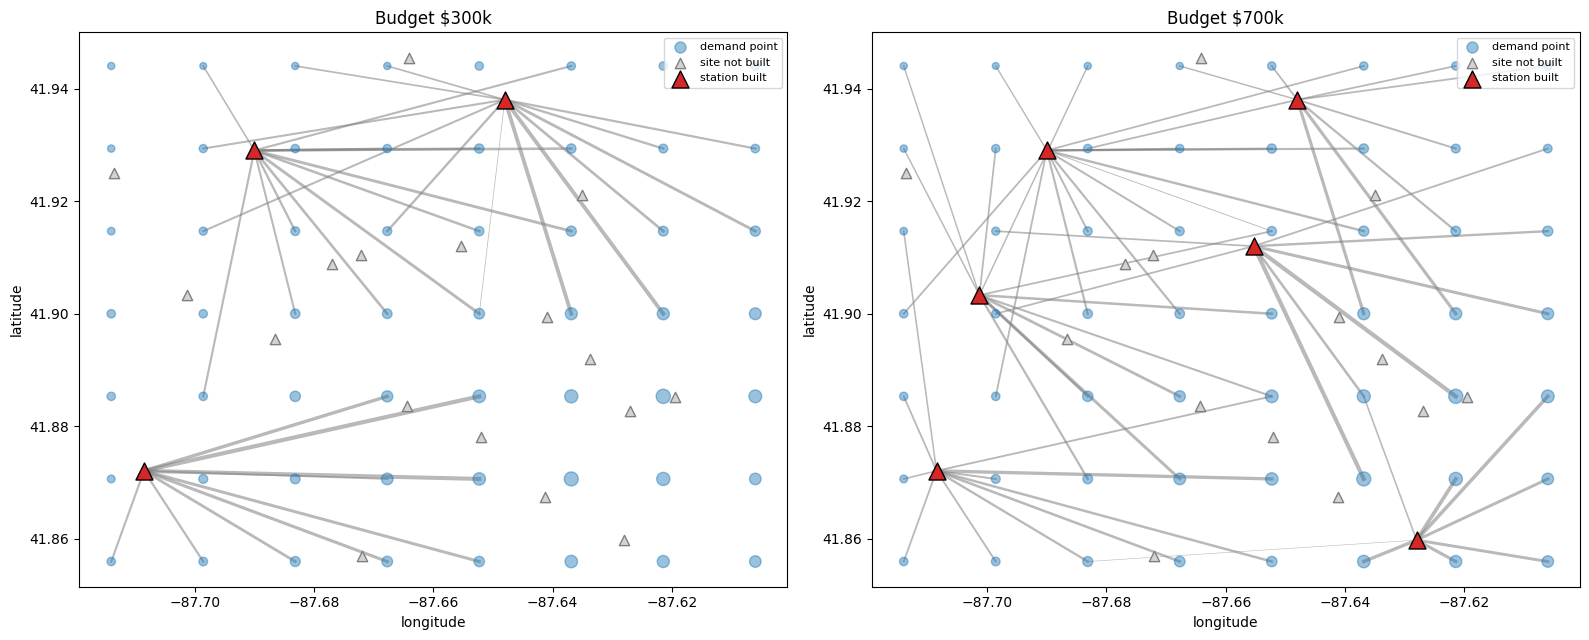

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
low  = solve_model(sites, demands, D, budget=300_000, radius=RADIUS, mode='max_coverage')
high = solve_model(sites, demands, D, budget=700_000, radius=RADIUS, mode='max_coverage')
plot_solution(low,  sites, demands, ax=axes[0], title='Budget $300k')
plot_solution(high, sites, demands, ax=axes[1], title='Budget $700k')
plt.tight_layout()
# plt.savefig('../figures/budget_comparison.png', dpi=150)
plt.show()

## 2.6 Decision support tool

This is its own line on the grading rubric. Wrap the model so a planner can test scenarios without touching any modeling code.

**TODO**: finish `recommend()` and demo it two or three times with different budgets.

Recommended plan for a $400,000 budget
  stations to build: 4
  construction cost: $371,000
  demand covered   : 68.8%
  average drive    : 3.47 km


,site_id,amenity,lon,lat,cost
8,S08,parking,-87.7013,41.9033,95000
14,S14,parking,-87.7085,41.8721,95000
16,S16,parking,-87.6900,41.9290,88000
18,S18,parking,-87.6480,41.9380,93000


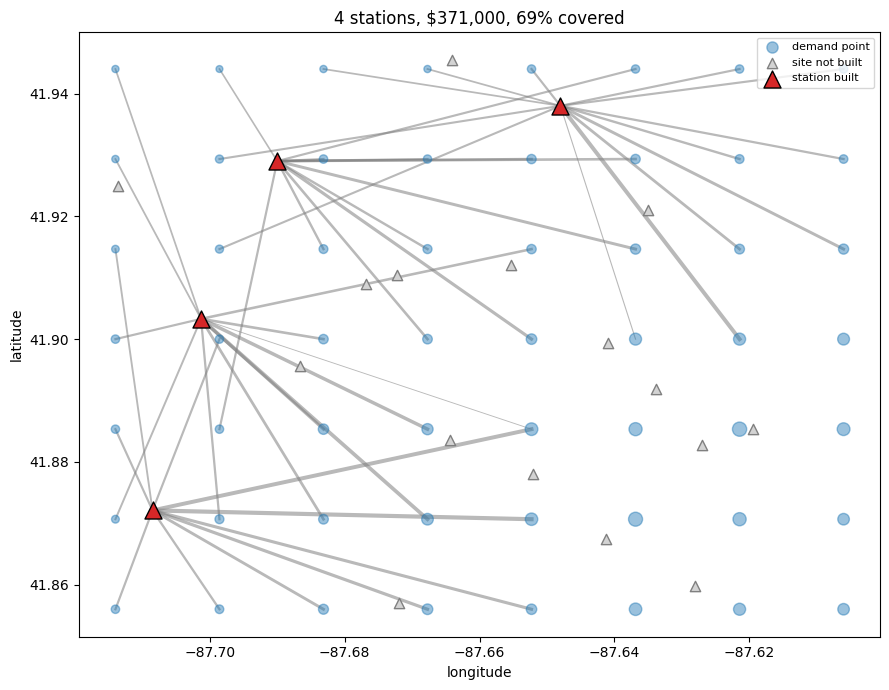

In [8]:
def recommend(budget, radius=5.0, mode='max_coverage'):
    """Given a budget, return and display the recommended build plan."""
    r = solve_model(sites, demands, D, budget=budget, radius=radius, mode=mode)
    if r['status'] != 'Optimal':
        print(f'No feasible plan at ${budget:,} with a {radius} km radius ({r["status"]}).')
        return r
    print(f'Recommended plan for a ${budget:,} budget')
    print(f'  stations to build: {len(r["built"])}')
    print(f'  construction cost: ${r["total_cost"]:,.0f}')
    print(f'  demand covered   : {r["coverage_pct"]:.1f}%')
    print(f'  average drive    : {r["avg_distance"]:.2f} km')
    display(sites.iloc[r['built']][['site_id', 'amenity', 'lon', 'lat', 'cost']])
    plot_solution(r, sites, demands)
    plt.tight_layout(); plt.show()
    return r

_ = recommend(400_000)

## 2.7 Conclusions

**TODO**: write these up for the report.

- Where is the knee of the budget curve, and what does it mean for a planner?
- Which sites get chosen no matter the budget? Those are the robust picks.
- Which assumption would change the answer most if it were wrong?
- What would you add with more time (road network distances instead of straight line, demand growth over time, existing stations already in the ground)?